# 02 - Preprocessing

### Credit Card Fraud Risk Detection & Transaction Risk Scoring

**Author: Corbin Couger**

Objective - Fix, transform, and balance data for ideal modeling conditions.

Dataset - [Kaggle Credit Card Fraud](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

---

Outline:

1. Drop duplicates
2. Feature engineering for the 'Amount' and 'Time' features
3. Train/Test Split
4. Standardize Train, Validation, & Test data
5. Apply SMOTE to training data
6. Save data for model steps

In [11]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
DATA_PATH = '../data/raw/creditcard.csv'

df = pd.read_csv(DATA_PATH)
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### 1. Drop Duplicates

In my EDA of this Credit Card Fraud risk dataset, I noticed few duplicates within the data. Though small, the need for an accurate, non-leaking model, I will need clean data. Hence why my first step in preprocessing is to drop the duplicates.

In [4]:
df_clean = df.drop_duplicates().reset_index(drop=True) # ensuring the index stays clean too
df_clean.head(3)

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0


### 2. Feature Engineer on 'Amount' and 'Time'

These two features, 'Amount' and 'Time', are what I need to transform for this data to be set for the model. Since these are the only two features that I know what they are (V1-V28 have unknown definitions), I will make sure they are scaled and fit into the parameters for the models I will be creating.

- **Amount:**

Since the majority of transactions are relatively small, this feature is heavily skewed. For some models, they have it handled, but for others it can cause issues as specific predictive models are sensitive to skewed data. I will compress this feature using the *log1p* as it handles 0 value transactions unlike the traditional log.

- **Time**

There are some nuances within time that us as humans know, like how midnight - 1am (hour 0) and 11pm - midnight (hour 23) are within the same hour apart from each other. The models does not see this... it sees these two frames as 23 hours apart. To negate this entirely, I will apply some math transformations to the hour variable, leaving the model to utilize it as a predictor and mitigates the model's assumptions on its relationships.


In [5]:
# Amount:

df_clean['Amount_log'] = np.log1p(df_clean['Amount'])

scaler = StandardScaler() # scaling this will help compress the mean

df_clean['Amount_scaled'] = scaler.fit_transform(df_clean[['Amount_log']])

# Time:

df_clean['Hour'] = (df_clean['Time'] / 3600) % 24

# will create a sin and cos version of time
df_clean['Hour_sin'] = np.sin(2 * np.pi * df_clean['Hour'] / 24)

df_clean['Hour_cos'] = np.cos(2 * np.pi * df_clean['Hour'] / 24)

# no longer will need the original columns and the initial ones I created
df_clean = df_clean.drop(columns = ['Time', 'Amount', 'Amount_log', 'Hour'])

In [6]:
df_clean.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V23,V24,V25,V26,V27,V28,Class,Amount_scaled,Hour_sin,Hour_cos
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,1.123062,0.000000,1.0
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-1.115298,0.000000,1.0
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.680981,0.000073,1.0
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,1.008128,0.000073,1.0
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,0.669117,0.000145,1.0


### 3. Train / Test Split

Next up is splitting the data. Unlike traditional train and test splitting, I want to add in a validation set too for the data and models. This is done before scaling and SMOTE to prevent any sort of 'false' evaulation metrics during modeling as applying these here can create some data bleeding.

In [7]:
X = df_clean.drop(columns = ['Class'])
y = df_clean['Class']

In [8]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size= .15,
    random_state=42,
    stratify=y # this is due to the 'fraud' data being such a low percentage of the data
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=.176,
    random_state=42,
    stratify=y_temp
)

print(f'Train Shape: {X_train.shape}')
print(f'Validation Shape: {X_val.shape}')
print(f'Test Shape: {X_test.shape}')

Train Shape: (198721, 31)
Validation Shape: (42446, 31)
Test Shape: (42559, 31)


##### **Notes:**

As I can see, the split went well, the Validation and Test sizes being roughly the same shape and the training data having nearly 70% of the data.

### 4. Standardize Data

In [9]:
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

##### **Notes:**

I scaled all of the features within the dataset. V1-V28 were already put through Principal Component Analysis (PCA) before this data was published, so those variables should already have a clean structure but I still scaled these features to retain consistency.

### 5. Apply SMOTE Oversampling Method

I will next fix imbalance between the fraud and legit transactions within the training datasets.

In [10]:
smote = SMOTE(sampling_strategy='minority', random_state=42)

X_train_sm, y_train_sm = smote.fit_resample(X_train_scaled, y_train)

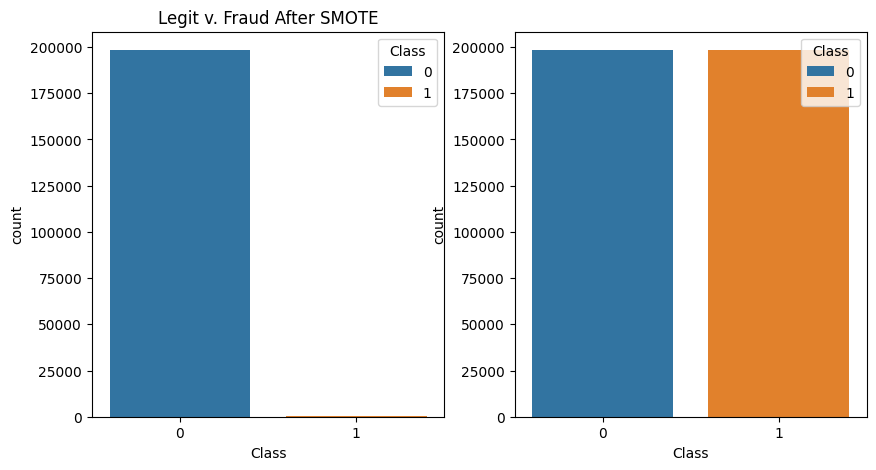

In [23]:
fig, axes = plt.subplots(1, 2, figsize = (10,5))

sns.barplot(data = y_train.value_counts().reset_index(), x = 'Class', y = 'count', hue = 'Class', ax=axes[0])
axes[0].set_title('Legit v. Fraud Before SMOTE')

sns.barplot(data = y_train_sm.value_counts().reset_index(), x = 'Class', y = 'count', hue = 'Class', ax=axes[1])
axes[0].set_title('Legit v. Fraud After SMOTE')

plt.show()

##### **Notes:**

The data is now balanced, I took the approach to oversample the minority class (fraud). All that is left in this phase is to save the preprossed data.

### 6. Export Preprocessed Data

In [32]:
import os
import pickle

os.makedirs('../data/processed', exist_ok=True)

X_train_sm = pd.DataFrame(X_train_sm, columns=X_train.columns)
y_train_sm = pd.Series(y_train_sm, name = 'Class')

X_val_scaled = pd.DataFrame(X_val_scaled, columns=X_val.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

X_train_sm.to_csv('../data/processed/X_train.csv', index = False)
X_val_scaled.to_csv('../data/processed/X_val.csv', index = False)
X_test_scaled.to_csv('../data/processed/X_test.csv', index = False)

y_train_sm.to_csv('../data/processed/y_train.csv', index = False)
y_val.to_csv('../data/processed/y_val.csv', index = False)
y_test.to_csv('../data/processed/y_test.csv', index = False)

with open('../data/processed/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

Next up, file '03_modeling,ipynb'